# **Net Post-Purification Dividend Safety**

This study asks whether **Halal high-dividend** screens should rank stocks by **gross yield** or by **net yield after purifying impure income**, and whether requiring **free-cash-flow coverage** of that dividend keeps the book safer.

After dropping banned businesses and names above the AAOIFI debt cap (`< 30%`), we:

1. Keep names with known impure income below the **5%** threshold
2. Require **FCF coverage ≥ 1** (TTM free cash flow covers TTM dividends)
3. Rank by **net post-purification yield** \(Y^{net} = Y^{gross} \times (1 - \rho)\) and own the top slice **in proportion to company size**

**White-paper focus:** design post-purification yield optimization so dividend drag is minimized *before* names enter the book — not only reported after the fact.

**Control twin:** same Halal + coverage rules, ranked by **gross** yield instead of net yield.


## Setup

Install dependencies and configure the backtest window.

`FAST_MODE = False` uses the full S&P 500 (slower: SEC / yfinance calls). Keep it `True` only for a smoke test. Performance stats start on the first day the strategy actually holds stocks, not on `START`.

**SEC fundamentals:** AAOIFI screens need SEC EDGAR history. The setup cell installs the local `halalquant` repo (`Development/halalquant`) when present, otherwise PyPI. Set `HALALQUANT_SEC_UA` to your name and email if SEC requests fail. **Restart the kernel** after the first setup run so imports pick up the updated package.


In [11]:
import os
import subprocess
import sys
from datetime import date
from io import StringIO
from pathlib import Path

import requests
from IPython.display import display


def resolve_notebook_dir() -> Path:
    """Jupyter sometimes loses cwd(); find this notebook's folder reliably."""
    candidates = [Path.cwd()]
    candidates.append(
        Path.home() / "Documents/Development/Monterey-Finance/Research/papers/07-net-div-safety"
    )
    for path in candidates:
        try:
            resolved = path.resolve()
        except OSError:
            continue
        if resolved.is_dir() and (resolved / "code.ipynb").exists():
            return resolved
    return Path.cwd()


NB_DIR = resolve_notebook_dir()
os.chdir(NB_DIR)

HQ_ROOT = NB_DIR.parents[3] / "halalquant"
PIP_DEPS = ["yfinance", "matplotlib", "requests", "lxml", "html5lib"]

if HQ_ROOT.is_dir() and (HQ_ROOT / "pyproject.toml").exists():
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "-e", str(HQ_ROOT)],
        cwd=str(NB_DIR),
        check=False,
    )
    hq_src = str(HQ_ROOT)
    if hq_src not in sys.path:
        sys.path.insert(0, hq_src)
else:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "halalquant"] + PIP_DEPS,
        cwd=str(NB_DIR),
        check=False,
    )

subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q"] + PIP_DEPS,
    cwd=str(NB_DIR),
    check=False,
)

os.environ.setdefault(
    "HALALQUANT_SEC_UA",
    "Monterey Finance Research halalquant/0.1.0 research@montereyfinance.com",
)

import warnings

import halalquant as hq
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf
from halalquant.providers._yfinance import YFinanceProvider
from halalquant.screening._aaoifi import AAOIFIScreener
from halalquant.screening._sector_filter import SectorFilter

warnings.filterwarnings("ignore", category=FutureWarning)

# --- Backtest configuration ---
START = "2020-01-01"
END = "2025-12-31"
KEEP_QUANTILE = 0.20          # top quintile by net (or gross) yield
MIN_HOLDINGS = 8              # skip a rebalance if the screen is too thin
MIN_COVERAGE = 1.0            # TTM FCF / TTM dividends
IMPURE_MAX = 0.05             # AAOIFI-style impure income threshold
REBALANCE_FREQ = "ME"         # "ME" = monthly, "QE" = quarterly
DEBT_THRESHOLD = 0.30         # AAOIFI debt / 24m market cap limit
FILING_LAG_DAYS = 90          # conservative PIT lag for yfinance statement dates
FAST_MODE = False             # True → 60 names (smoke test); False → full S&P 500 for the paper
RISK_FREE_RATE = 0.02
COST_BPS = 10
STRATEGY_LABEL = "Net-yield dividend safety"
GROSS_LABEL = "Gross-yield twin"   # same screens, ranked by gross yield

BENCHMARKS = {
    "SPY": "SPY",
    "S&P 500": "^GSPC",
    "SPUS": "SPUS",
}

print(f"notebook dir: {NB_DIR}")
print(f"halalquant v{hq.__version__} from {Path(hq.__file__).resolve().parent.parent}")
print(f"Window: {START} → {END}  FAST_MODE={FAST_MODE}  MIN_HOLDINGS={MIN_HOLDINGS}")



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip


notebook dir: /Users/raoabdul/Documents/Development/Monterey-Finance/Research/papers/07-net-div-safety
halalquant v0.1.0 from /opt/homebrew/lib/python3.11/site-packages
Window: 2020-01-01 → 2025-12-31  FAST_MODE=False  MIN_HOLDINGS=8



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip


## Step 1 — Start with a universe of stocks

We use **S&P 500 constituents** as the broad US equity universe, then pre-filter excluded business activities (banks, alcohol, gambling, etc.) using `halalquant`'s sector screen.


In [12]:
FALLBACK_SP500 = [
    "AAPL", "MSFT", "GOOGL", "AMZN", "NVDA", "META", "BRK-B", "LLY", "AVGO", "JPM",
    "UNH", "XOM", "V", "MA", "PG", "COST", "HD", "JNJ", "ABBV", "NFLX",
    "CRM", "MRK", "AMD", "PEP", "KO", "TMO", "ADBE", "WMT", "CSCO", "ACN",
    "MCD", "LIN", "ABT", "DHR", "INTC", "CMCSA", "TXN", "QCOM", "INTU", "AMAT",
    "DIS", "IBM", "GE", "CAT", "NOW", "VZ", "AMGN", "PFE", "ISRG", "GS",
    "PM", "T", "MO", "CVX", "COP", "NEE", "BMY", "MDT", "UPS", "HON",
]


def load_sp500_tickers() -> list[str]:
    """Fetch current S&P 500 symbols from Wikipedia (with offline fallback)."""
    url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
    headers = {"User-Agent": "MontereyFinanceResearch/1.0 (halal-quant-notebook)"}
    try:
        response = requests.get(url, headers=headers, timeout=30)
        response.raise_for_status()
        table = pd.read_html(StringIO(response.text), attrs={"id": "constituents"})[0]
        return (
            table["Symbol"]
            .astype(str)
            .str.replace(".", "-", regex=False)
            .tolist()
        )
    except Exception as exc:
        print(f"Could not fetch S&P 500 list ({exc}); using fallback basket.")
        return FALLBACK_SP500.copy()


def apply_sector_screen(tickers: list[str]) -> tuple[list[str], pd.DataFrame, dict[str, str]]:
    """Remove non-compliant sectors before financial ratio screens run."""
    provider = YFinanceProvider()
    sector_map = provider.get_sector_map(tickers)
    sector_filter = SectorFilter()
    kept = sector_filter.filter_symbols(tickers, sector_map=sector_map)
    audit = pd.DataFrame(sector_filter.audit_log)
    return kept, audit, sector_map


raw_universe = load_sp500_tickers()
if FAST_MODE:
    raw_universe = raw_universe[:60]
    print("FAST_MODE is on — smoke-test universe only. Set FAST_MODE = False for the paper.\n")

eligible_universe, sector_audit, activity_labels = apply_sector_screen(raw_universe)

print(f"Raw universe:      {len(raw_universe)} tickers")
print(f"After sector screen: {len(eligible_universe)} tickers")
print(f"Removed by sector:   {len(raw_universe) - len(eligible_universe)}")

sector_audit.head(10)


Raw universe:      503 tickers
After sector screen: 439 tickers
Removed by sector:   64


,symbol,sector,reason
0,AFL,conventional insurance,excluded business activity
1,ALL,conventional insurance,excluded business activity
2,MO,tobacco,excluded business activity
3,AXP,conventional banking,excluded business activity
4,AIG,conventional insurance,excluded business activity
5,AON,conventional insurance,excluded business activity
6,ACGL,conventional insurance,excluded business activity
7,AJG,conventional insurance,excluded business activity
8,AIZ,conventional insurance,excluded business activity
9,AXON,defense,excluded business activity


## Steps 2–6 — Filter, score net yield, select, rebalance

Pipeline at each rebalance date (point-in-time, no look-ahead):

1. **FILTER** — AAOIFI screens (`debt < 30%`, cash & receivables caps) and impure ratio `< 5%`
2. **SCORE** — gross dividend yield, impure haircut → **net yield**, and **FCF coverage** of TTM dividends
3. **SELECT** — require coverage `≥ 1`, then keep the top `KEEP_QUANTILE` by **net yield**
4. **WEIGHT** — capitalisation weights (long-only)
5. **REBALANCE** — monthly (`REBALANCE_FREQ = "ME"`)

Need at least `MIN_HOLDINGS` names or that month is skipped. Performance starts on the first day the strategy actually holds stocks.

A **gross-yield twin** uses the same Halal + coverage filters, then ranks by gross yield instead of net yield — so any edge is the purification haircut, not a different coverage rule.


In [13]:
def build_fcf_history(symbols: list[str], filing_lag_days: int = FILING_LAG_DAYS) -> pd.DataFrame:
    """Annual free cash flow history with a conservative public filing lag."""
    rows: list[dict] = []
    n_symbols = len(symbols)
    for i, symbol in enumerate(symbols, 1):
        if i == 1 or i % 50 == 0 or i == n_symbols:
            print(f"  FCF history {i}/{n_symbols}", flush=True)
        try:
            cashflow = yf.Ticker(symbol).cashflow
        except Exception:
            continue
        if cashflow is None or cashflow.empty:
            continue

        if "Free Cash Flow" in cashflow.index:
            fcf_label = "Free Cash Flow"
            capex = None
        elif "Operating Cash Flow" in cashflow.index:
            fcf_label = "Operating Cash Flow"
            capex = cashflow.loc["Capital Expenditure"] if "Capital Expenditure" in cashflow.index else None
        else:
            continue

        for period_end in cashflow.columns:
            if fcf_label == "Free Cash Flow":
                fcf = cashflow.at[fcf_label, period_end]
            else:
                ocf = cashflow.at[fcf_label, period_end]
                cap = capex.at[period_end] if capex is not None else np.nan
                fcf = ocf + cap if pd.notna(cap) else ocf  # CapEx is usually negative

            if pd.isna(fcf):
                continue

            report_ts = pd.Timestamp(period_end).normalize()
            filed_ts = report_ts + pd.Timedelta(days=filing_lag_days)
            rows.append(
                {
                    "symbol": symbol,
                    "report_date": report_ts.date(),
                    "filed_date": filed_ts.date(),
                    "fcf": float(fcf),
                }
            )

    return pd.DataFrame(rows)


def build_dividend_history(symbols: list[str]) -> pd.DataFrame:
    """Cash dividend events from yfinance (ex-date, amount per share)."""
    rows: list[dict] = []
    n_symbols = len(symbols)
    for i, symbol in enumerate(symbols, 1):
        if i == 1 or i % 50 == 0 or i == n_symbols:
            print(f"  Dividend history {i}/{n_symbols}", flush=True)
        try:
            divs = yf.Ticker(symbol).dividends
        except Exception:
            continue
        if divs is None or len(divs) == 0:
            continue
        series = divs.copy()
        idx = pd.to_datetime(series.index)
        if getattr(idx, "tz", None) is not None:
            idx = idx.tz_convert("UTC").tz_localize(None)
        series.index = idx
        for ex_date, amount in series.items():
            if pd.isna(amount) or float(amount) <= 0:
                continue
            rows.append(
                {
                    "symbol": symbol,
                    "ex_date": pd.Timestamp(ex_date).normalize().date(),
                    "dividend": float(amount),
                }
            )
    return pd.DataFrame(rows)


def attach_latest_fcf(metrics: pd.DataFrame, fcf_history: pd.DataFrame) -> pd.DataFrame:
    """Join the latest FCF filing known on each metrics snapshot date."""
    if metrics.empty or fcf_history.empty:
        out = metrics.copy()
        out["fcf"] = np.nan
        return out

    fcf = fcf_history.copy()
    fcf["filed_date"] = pd.to_datetime(fcf["filed_date"])
    fcf["report_date"] = pd.to_datetime(fcf["report_date"])

    pieces: list[pd.DataFrame] = []
    for as_of, snap in metrics.groupby("as_of", sort=True):
        as_of_ts = pd.Timestamp(as_of)
        snap = snap.copy()
        fcf_values: list[float] = []
        for _, row in snap.iterrows():
            known = fcf[(fcf["symbol"] == row["symbol"]) & (fcf["filed_date"] <= as_of_ts)]
            if known.empty:
                fcf_values.append(np.nan)
            else:
                fcf_values.append(float(known.sort_values("report_date").iloc[-1]["fcf"]))
        snap["fcf"] = fcf_values
        pieces.append(snap)
    return pd.concat(pieces, ignore_index=True)


def ttm_dividends_per_share(
    dividend_history: pd.DataFrame,
    symbol: str,
    as_of,
) -> float:
    """Sum of cash dividends with ex-dates in the trailing 365 days ending as_of."""
    if dividend_history.empty:
        return np.nan
    as_of_ts = pd.Timestamp(as_of)
    start = as_of_ts - pd.Timedelta(days=365)
    known = dividend_history[
        (dividend_history["symbol"] == symbol)
        & (pd.to_datetime(dividend_history["ex_date"]) > start)
        & (pd.to_datetime(dividend_history["ex_date"]) <= as_of_ts)
    ]
    if known.empty:
        return 0.0
    return float(known["dividend"].sum())


def price_on_or_before(price_panel: pd.DataFrame, symbol: str, as_of) -> float:
    if symbol not in price_panel.columns:
        return np.nan
    s = price_panel[symbol].dropna().loc[: pd.Timestamp(as_of)]
    return float(s.iloc[-1]) if not s.empty else np.nan


def assign_cap_weights(selected: pd.DataFrame) -> pd.DataFrame:
    """Bigger firms get more of the book. Equal-weight if market cap is unusable."""
    out = selected.copy()
    if out.empty:
        out["weight"] = pd.Series(dtype=float)
        return out
    cap = pd.to_numeric(out["market_cap"], errors="coerce").clip(lower=0)
    total = float(cap.sum(skipna=True))
    if np.isfinite(total) and total > 0:
        out["weight"] = cap / total
        out["weight"] = out["weight"].fillna(0.0)
        wsum = float(out["weight"].sum())
        out["weight"] = out["weight"] / wsum if wsum > 0 else 1.0 / len(out)
    else:
        out["weight"] = 1.0 / len(out)
    return out


def score_dividend_safety(
    panel: pd.DataFrame,
    price_panel: pd.DataFrame,
    dividend_history: pd.DataFrame,
    as_of: date,
) -> pd.DataFrame:
    """Attach TTM dividends, yields, impure haircut, and FCF coverage as of as_of."""
    out = panel.copy()
    if out.empty:
        return out

    prices, ttm_divs, shares_proxy = [], [], []
    for _, row in out.iterrows():
        sym = row["symbol"]
        px = price_on_or_before(price_panel, sym, as_of)
        ttm = ttm_dividends_per_share(dividend_history, sym, as_of)
        prices.append(px)
        ttm_divs.append(ttm)
        # Approximate shares outstanding from market cap / price when available
        cap = pd.to_numeric(row.get("market_cap"), errors="coerce")
        if pd.notna(px) and px > 0 and pd.notna(cap) and cap > 0:
            shares_proxy.append(float(cap) / float(px))
        else:
            shares_proxy.append(np.nan)

    out["price"] = prices
    out["ttm_div_ps"] = ttm_divs
    out["shares_proxy"] = shares_proxy
    out["ttm_dividends"] = out["ttm_div_ps"] * out["shares_proxy"]
    out["gross_yield"] = out["ttm_div_ps"] / out["price"].replace(0, np.nan)

    impure = pd.to_numeric(out.get("impure_ratio"), errors="coerce")
    out["impure_ratio"] = impure
    out["net_yield"] = out["gross_yield"] * (1.0 - impure.clip(lower=0.0, upper=1.0))

    fcf = pd.to_numeric(out.get("fcf"), errors="coerce")
    ttm_div_usd = pd.to_numeric(out["ttm_dividends"], errors="coerce")
    out["coverage"] = fcf / ttm_div_usd.replace(0, np.nan)
    return out


def select_dividend_safety(
    panel: pd.DataFrame,
    price_panel: pd.DataFrame,
    dividend_history: pd.DataFrame,
    as_of: date,
    rank_col: str = "net_yield",
    keep_quantile: float = KEEP_QUANTILE,
    min_holdings: int = MIN_HOLDINGS,
    min_coverage: float = MIN_COVERAGE,
    impure_max: float = IMPURE_MAX,
    screener: AAOIFIScreener | None = None,
) -> pd.DataFrame:
    """FILTER (Halal + impure) → SCORE → coverage floor → top quantile by rank_col → cap-weight."""
    empty_cols = [
        "symbol", "gross_yield", "net_yield", "coverage", "impure_ratio",
        "fcf", "ttm_div_ps", "market_cap", "weight",
        "debt_ratio", "cash_ratio", "receivables_ratio",
    ]
    screener = screener or AAOIFIScreener(debt_threshold=DEBT_THRESHOLD)
    as_of_d = pd.Timestamp(as_of).date()
    snap = panel[pd.to_datetime(panel["as_of"]).dt.date == as_of_d].copy()
    if snap.empty:
        return pd.DataFrame(columns=empty_cols)

    screened = screener.evaluate_compliance(snap)
    snap = snap.drop(columns=[c for c in ("debt_ratio", "cash_ratio", "receivables_ratio") if c in snap.columns])
    passed = snap.merge(screened, on="symbol", how="inner")
    passed = passed[passed["is_compliant"].fillna(False)].copy()
    passed = score_dividend_safety(passed, price_panel, dividend_history, as_of)

    impure = pd.to_numeric(passed["impure_ratio"], errors="coerce")
    passed = passed[
        pd.to_numeric(passed["market_cap"], errors="coerce").gt(0)
        & passed["gross_yield"].notna()
        & passed["gross_yield"].gt(0)
        & passed["net_yield"].notna()
        & np.isfinite(passed["net_yield"])
        & impure.notna()
        & impure.lt(impure_max)
        & passed["coverage"].notna()
        & np.isfinite(passed["coverage"])
        & passed["coverage"].ge(min_coverage)
        & pd.to_numeric(passed["fcf"], errors="coerce").gt(0)
    ].copy()

    if passed.empty:
        return pd.DataFrame(columns=empty_cols)

    effective_min = min(min_holdings, max(3, len(passed)))
    if len(passed) < 3:
        return pd.DataFrame(columns=empty_cols)

    cutoff = passed[rank_col].quantile(1.0 - keep_quantile)
    selected = passed[passed[rank_col] >= cutoff].copy()
    if len(selected) < effective_min:
        selected = passed.nlargest(effective_min, rank_col).copy()

    selected = assign_cap_weights(selected)
    keep = [c for c in empty_cols if c in selected.columns]
    return selected[keep].sort_values("weight", ascending=False)


def run_dividend_safety_backtest(
    metrics: pd.DataFrame,
    fcf_history: pd.DataFrame,
    dividend_history: pd.DataFrame,
    prices: pd.DataFrame,
    rank_col: str = "net_yield",
    keep_quantile: float = KEEP_QUANTILE,
    min_holdings: int = MIN_HOLDINGS,
) -> tuple[pd.DataFrame, pd.DataFrame, list[date]]:
    """Cap-weighted Halal dividend-safety book. Pre-live days are missing, not 0%."""
    panel = attach_latest_fcf(metrics, fcf_history)
    screener = AAOIFIScreener(debt_threshold=DEBT_THRESHOLD)

    price_panel = (
        prices.pivot(index="date", columns="symbol", values="adj_close")
        .sort_index()
        .ffill()
    )
    price_panel.index = pd.to_datetime(price_panel.index)
    daily_returns = price_panel.pct_change(fill_method=None)

    rebalance_dates = sorted(pd.to_datetime(panel["as_of"].dropna().unique()).date)
    weights_by_date: dict[date, pd.Series] = {}
    selection_log: list[pd.DataFrame] = []

    for as_of in rebalance_dates:
        picks = select_dividend_safety(
            panel,
            price_panel,
            dividend_history,
            as_of=as_of,
            rank_col=rank_col,
            keep_quantile=keep_quantile,
            min_holdings=min_holdings,
            screener=screener,
        )
        if picks.empty:
            weights_by_date[as_of] = pd.Series(dtype=float)
        else:
            weights_by_date[as_of] = picks.set_index("symbol")["weight"].astype(float)
            selection_log.append(picks.assign(as_of=as_of))

    selection_df = (
        pd.concat(selection_log, ignore_index=True)
        if selection_log
        else pd.DataFrame(columns=["symbol", "net_yield", "gross_yield", "weight", "as_of"])
    )

    port_rows: list[dict] = []
    active_w = pd.Series(dtype=float)
    last_rebalance: date | None = None
    live = False

    for dt in daily_returns.index:
        if dt.date() < pd.Timestamp(START).date():
            continue

        prior = [d for d in rebalance_dates if pd.Timestamp(d) <= dt]
        if prior and prior[-1] != last_rebalance:
            active_w = weights_by_date.get(prior[-1], pd.Series(dtype=float))
            last_rebalance = prior[-1]
            if not active_w.empty:
                live = True

        if not live:
            port_rows.append({"date": dt.date(), "return": np.nan, "n_holdings": 0})
            continue

        if active_w.empty:
            port_rows.append({"date": dt.date(), "return": 0.0, "n_holdings": 0})
            continue

        held = [s for s in active_w.index if s in daily_returns.columns]
        w = active_w.reindex(held).astype(float)
        w = w[w > 0]
        if w.empty:
            port_rows.append({"date": dt.date(), "return": 0.0, "n_holdings": 0})
            continue
        w = w / w.sum()
        day_ret = (daily_returns.loc[dt, w.index] * w).sum(skipna=True)
        port_rows.append({
            "date": dt.date(),
            "return": 0.0 if pd.isna(day_ret) else float(day_ret),
            "n_holdings": int(len(w)),
        })

    port_returns = pd.DataFrame(port_rows)
    port_returns["date"] = pd.to_datetime(port_returns["date"])
    return port_returns, selection_df, rebalance_dates


def calc_performance_stats(daily_returns: pd.Series, label: str, rf: float = RISK_FREE_RATE) -> dict:
    """CAGR, volatility, Sharpe, Sortino, max drawdown, Calmar."""
    r = daily_returns.dropna()
    if r.empty:
        return {
            "Strategy": label, "CAGR": np.nan, "Volatility": np.nan, "Sharpe": np.nan,
            "Sortino": np.nan, "Max Drawdown": np.nan, "Calmar": np.nan,
        }

    equity = (1 + r).cumprod()
    years = len(r) / 252
    cagr = equity.iloc[-1] ** (1 / years) - 1 if years > 0 else np.nan
    vol = r.std() * np.sqrt(252)
    excess = r - rf / 252
    sharpe = excess.mean() / excess.std() * np.sqrt(252) if excess.std() > 0 else np.nan
    downside = r[r < 0]
    sortino = (r.mean() - rf / 252) / downside.std() * np.sqrt(252) if len(downside) else np.nan
    dd = equity / equity.cummax() - 1
    max_dd = dd.min()
    calmar = cagr / abs(max_dd) if max_dd < 0 else np.nan

    return {
        "Strategy": label,
        "CAGR": cagr,
        "Volatility": vol,
        "Sharpe": sharpe,
        "Sortino": sortino,
        "Max Drawdown": max_dd,
        "Calmar": calmar,
    }


print("Helpers ready: FCF / dividends / net yield / coverage / backtest")


Helpers ready: FCF / dividends / net yield / coverage / backtest


### Download prices, fundamentals, FCF, and dividends

**What this code cell does:**
- Builds point-in-time FCF history (Yahoo annual cash-flow + filing lag)
- Builds cash dividend histories for TTM yield and coverage
- Pulls AAOIFI financial snapshots (includes `impure_ratio` when available)
- Downloads adjusted prices for eligible stocks plus SPY / ^GSPC / SPUS


In [ ]:
print("Fetching FCF history …")
fcf_history = build_fcf_history(eligible_universe)
print(f"  {fcf_history['symbol'].nunique() if not fcf_history.empty else 0} symbols with FCF data")

print("Fetching dividend history …")
dividend_history = build_dividend_history(eligible_universe)
print(
    f"  {dividend_history['symbol'].nunique() if not dividend_history.empty else 0} symbols with dividends  ·  "
    f"{len(dividend_history)} events"
)

print("Fetching point-in-time AAOIFI metrics …")
metrics = hq.get_financial_metrics(
    eligible_universe,
    start=START,
    end=END,
    freq=REBALANCE_FREQ,
)
print(f"  {metrics.shape[0]} snapshot rows")

# halalquant.validate_symbols rejects index tickers like ^GSPC — fetch those via yfinance.
hq_ok = {t for t in set(BENCHMARKS.values()) if t.replace(".", "").replace("-", "").isalnum()}
index_tickers = sorted(set(BENCHMARKS.values()) - hq_ok)
all_symbols = sorted(set(eligible_universe) | hq_ok)

print("Downloading price history …")
prices = hq.download(all_symbols, start=START, end=END)
prices["date"] = pd.to_datetime(prices["date"])

if index_tickers:
    print(f"  Fetching index benchmarks via yfinance: {index_tickers}")
    raw = yf.download(
        index_tickers,
        start=START,
        end=END,
        auto_adjust=False,
        progress=False,
        group_by="ticker",
        threads=False,
    )
    index_frames = []
    for ticker in index_tickers:
        if isinstance(raw.columns, pd.MultiIndex):
            if ticker not in raw.columns.get_level_values(0):
                print(f"  Warning: no data for {ticker}")
                continue
            sub = raw[ticker].copy()
        else:
            sub = raw.copy()
        sub = sub.rename(columns=str.title)
        adj = sub["Adj Close"] if "Adj Close" in sub.columns else sub["Close"]
        dates = pd.to_datetime(sub.index)
        if getattr(dates, "tz", None) is not None:
            dates = dates.tz_convert("UTC").tz_localize(None)
        frame = pd.DataFrame({
            "symbol": ticker,
            "date": dates,
            "open": sub.get("Open"),
            "high": sub.get("High"),
            "low": sub.get("Low"),
            "close": sub.get("Close"),
            "volume": sub.get("Volume"),
            "adj_close": adj,
        })
        index_frames.append(frame.dropna(subset=["adj_close"]))
    if index_frames:
        prices = pd.concat([prices, *index_frames], ignore_index=True)

print(f"  {prices['symbol'].nunique()} symbols, {prices['date'].nunique()} trading days")

# Impure-ratio coverage in the metrics panel (selection requires non-null)
if "impure_ratio" in metrics.columns:
    impure_cov = metrics["impure_ratio"].notna().mean()
    print(f"Impure-ratio coverage in metrics: {impure_cov:.1%}")
else:
    print("WARNING: metrics panel has no impure_ratio column — net yield cannot be scored.")

metrics.head()


Fetching FCF history …
  FCF history 1/439
  FCF history 50/439
  FCF history 100/439
  FCF history 150/439


### Run the backtest

**What this code cell does:**
- Sanity-checks the last rebalance funnel: fundamentals → Halal → coverage-safe → net-yield picks
- Runs the main **net-yield** strategy and the **gross-yield twin**
- Prints holdings summary and the latest portfolio weights


In [ ]:
# Funnel on the last rebalance date
_as_of = sorted(pd.to_datetime(metrics["as_of"].dropna().unique()).date)[-1]
_panel = attach_latest_fcf(metrics, fcf_history)
_price_panel = (
    prices[prices["symbol"].isin(eligible_universe)]
    .pivot(index="date", columns="symbol", values="adj_close")
    .sort_index()
    .ffill()
)
_screener = AAOIFIScreener(debt_threshold=DEBT_THRESHOLD)
_snap = _panel[pd.to_datetime(_panel["as_of"]).dt.date == _as_of]
_halal = _snap.merge(_screener.evaluate_compliance(_snap), on="symbol", how="inner")
_halal = _halal[_halal["is_compliant"].fillna(False)]
_scored = select_dividend_safety(_panel, _price_panel, dividend_history, _as_of)
print(
    f"Funnel on {_as_of}: fundamentals={len(_snap)}  Halal={len(_halal)}  "
    f"net-yield picks={len(_scored)}  MIN_HOLDINGS={MIN_HOLDINGS}"
)
if not _scored.empty:
    print(
        f"Net yield range: {_scored['net_yield'].min():.2%} → {_scored['net_yield'].max():.2%}  "
        f"(median {_scored['net_yield'].median():.2%})  ·  "
        f"median coverage {_scored['coverage'].median():.2f}x"
    )

strategy_returns, selections, rebalance_dates = run_dividend_safety_backtest(
    metrics=metrics,
    fcf_history=fcf_history,
    dividend_history=dividend_history,
    prices=prices[prices["symbol"].isin(eligible_universe)],
    rank_col="net_yield",
)

gross_returns, gross_selections, _ = run_dividend_safety_backtest(
    metrics=metrics,
    fcf_history=fcf_history,
    dividend_history=dividend_history,
    prices=prices[prices["symbol"].isin(eligible_universe)],
    rank_col="gross_yield",
)

live_dates = strategy_returns.loc[strategy_returns["return"].notna(), "date"]
holdings_per_date = selections.groupby("as_of")["symbol"].nunique() if not selections.empty else pd.Series(dtype=int)

print(f"\nRebalance dates with data: {len(rebalance_dates)}")
print(f"First invested date:       {live_dates.min().date() if not live_dates.empty else 'n/a'}")
print(f"Last rebalance:            {rebalance_dates[-1] if rebalance_dates else 'n/a'}")
if not holdings_per_date.empty:
    print(
        "Holdings per live rebalance: "
        f"min={int(holdings_per_date.min())}  "
        f"median={holdings_per_date.median():.0f}  "
        f"max={int(holdings_per_date.max())}"
    )

print(f"\nLatest holdings ({rebalance_dates[-1] if rebalance_dates else 'n/a'}) — largest weights first:")
if rebalance_dates and not selections.empty:
    latest = selections[selections["as_of"] == rebalance_dates[-1]].copy()
    show = latest.copy()
    for col in ("gross_yield", "net_yield", "coverage", "impure_ratio", "weight", "debt_ratio"):
        if col in show.columns:
            if col == "coverage":
                show[col] = show[col].map(lambda x: f"{x:.2f}x" if pd.notna(x) else "—")
            else:
                show[col] = show[col].map(lambda x: f"{x:.2%}" if pd.notna(x) else "—")
    display(show.reset_index(drop=True))

    # How many names flip between net-yield and gross-yield ranking?
    if not gross_selections.empty:
        g_latest = set(gross_selections.loc[gross_selections["as_of"] == rebalance_dates[-1], "symbol"])
        n_latest = set(latest["symbol"])
        print(
            f"Overlap vs gross twin this month: {len(n_latest & g_latest)} / {len(n_latest)} "
            f"(net-only {sorted(n_latest - g_latest)}, gross-only {sorted(g_latest - n_latest)})"
        )
else:
    print("  (no compliant picks on last rebalance date)")


Funnel on 2025-12-31: fundamentals=49  Halal=31  net-yield picks=8  MIN_HOLDINGS=8
Net yield range: 0.54% → 2.89%  (median 1.56%)  ·  median coverage 2.74x

Rebalance dates with data: 72
First invested date:       2023-01-03
Last rebalance:            2025-12-31
Holdings per live rebalance: min=3  median=8  max=8

Latest holdings (2025-12-31) — largest weights first:


,symbol,gross_yield,net_yield,coverage,impure_ratio,fcf,ttm_div_ps,market_cap,weight,debt_ratio,cash_ratio,receivables_ratio,as_of
0,ABBV,2.92%,2.89%,1.50x,1.15%,1.783200e+10,6.560,4.073290e+11,31.41%,17.90%,0.016483,0.048882,2025-12-31
1,ABT,1.91%,1.90%,1.51x,0.82%,6.351000e+09,2.360,2.198634e+11,16.96%,6.00%,0.037850,0.070749,2025-12-31
2,AMAT,0.69%,0.68%,5.29x,1.43%,7.487000e+09,1.780,2.061562e+11,15.90%,4.31%,0.056388,0.090491,2025-12-31
3,ACN,1.68%,1.67%,3.79x,0.48%,1.087436e+10,4.440,1.707575e+11,13.17%,2.58%,0.057448,0.122802,2025-12-31
4,ADI,1.45%,1.44%,1.60x,0.96%,3.122066e+09,3.960,1.345667e+11,10.38%,7.93%,0.033724,0.046983,2025-12-31
5,ADP,2.49%,2.45%,1.68x,1.55%,4.392700e+09,6.320,1.051875e+11,8.11%,3.53%,0.069676,0.101458,2025-12-31
6,A,0.54%,0.54%,6.48x,0.89%,1.373000e+09,0.744,3.895394e+10,3.00%,8.93%,0.047656,0.087267,2025-12-31
7,ALLE,0.64%,0.63%,6.57x,0.54%,5.829000e+08,1.020,1.389823e+10,1.07%,16.49%,0.041557,0.041557,2025-12-31


Overlap vs gross twin this month: 8 / 8 (net-only [], gross-only [])


## Step 7 — Performance vs SPY, S&P 500, and SPUS

Compare the **net-yield dividend safety** book against **SPY**, the **S&P 500 index**, **SPUS**, and the **gross-yield twin**.

All numbers use the **live window only**.


Live window (net-yield): 2023-01-03 → 2025-12-30  (751 trading days)
Live window (gross twin): 2023-01-03 → 2025-12-30  (751 trading days)


,CAGR,Volatility,Sharpe,Sortino,Max Drawdown,Calmar
Strategy,,,,,,
Net-yield dividend safety,20.71%,15.87%,1.14,1.60,-16.27%,1.27
Gross-yield twin,20.71%,15.87%,1.14,1.60,-16.27%,1.27
SPY,23.35%,15.35%,1.31,1.76,-18.76%,1.24
S&P 500,21.71%,15.07%,1.25,1.68,-18.90%,1.15
SPUS,27.21%,17.56%,1.34,1.85,-22.82%,1.19


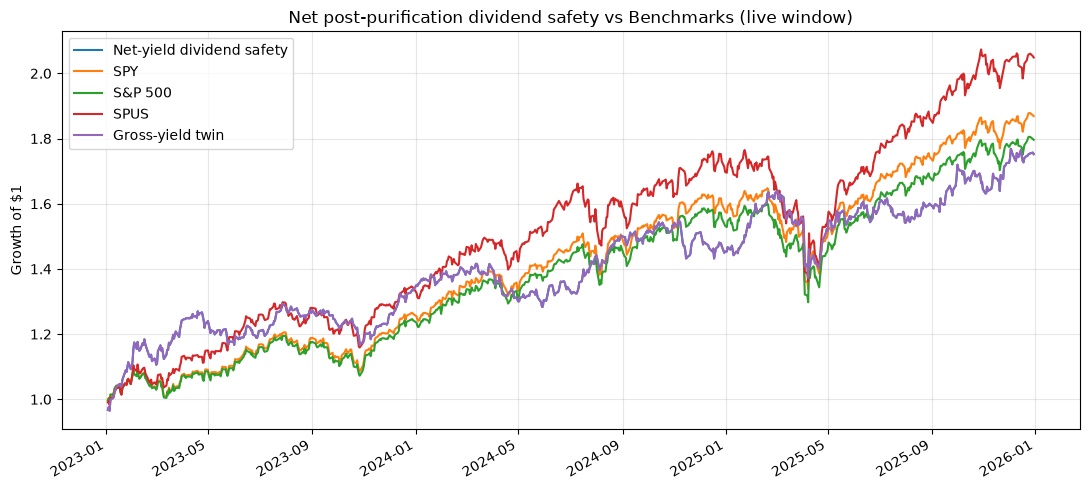

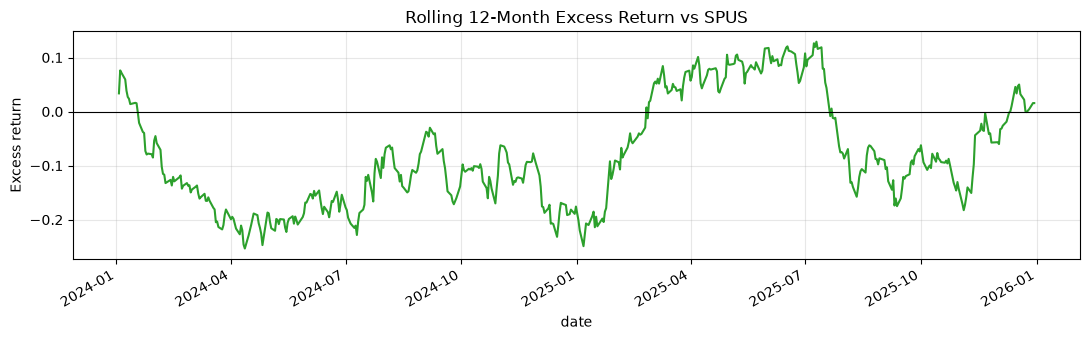

In [ ]:
def benchmark_returns(ticker: str) -> pd.Series:
    px = prices[prices["symbol"] == ticker].copy()
    px = px.sort_values("date").set_index("date")["adj_close"]
    return px.pct_change(fill_method=None).dropna()


def align_to_live(strategy: pd.Series, benches: dict[str, pd.Series]) -> pd.DataFrame:
    """Keep only days the strategy is live, and the same days for every benchmark."""
    panel = pd.DataFrame({"strategy": strategy})
    for name, series in benches.items():
        panel[name] = series
    return panel.dropna(how="any")


fig_dir = NB_DIR / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

bench_series = {name: benchmark_returns(ticker) for name, ticker in BENCHMARKS.items()}
strategy_s = strategy_returns.set_index("date")["return"].rename(STRATEGY_LABEL)
gross_s = gross_returns.set_index("date")["return"].rename(GROSS_LABEL)

main_panel = align_to_live(strategy_s, bench_series).rename(columns={"strategy": STRATEGY_LABEL})
gross_panel = align_to_live(gross_s, bench_series).rename(columns={"strategy": GROSS_LABEL})

if main_panel.empty:
    raise RuntimeError("No overlapping live days between the strategy and benchmarks.")

print(
    "Live window (net-yield): "
    f"{main_panel.index.min().date()} → {main_panel.index.max().date()}  "
    f"({len(main_panel)} trading days)"
)
if not gross_panel.empty:
    print(
        "Live window (gross twin): "
        f"{gross_panel.index.min().date()} → {gross_panel.index.max().date()}  "
        f"({len(gross_panel)} trading days)"
    )

rows = [calc_performance_stats(main_panel[STRATEGY_LABEL], STRATEGY_LABEL)]
if not gross_panel.empty:
    rows.append(calc_performance_stats(gross_panel[GROSS_LABEL], GROSS_LABEL))
for name in BENCHMARKS:
    rows.append(calc_performance_stats(main_panel[name], name))

performance = pd.DataFrame(rows).set_index("Strategy")
formatters = {
    "CAGR": "{:.2%}",
    "Volatility": "{:.2%}",
    "Sharpe": "{:.2f}",
    "Sortino": "{:.2f}",
    "Max Drawdown": "{:.2%}",
    "Calmar": "{:.2f}",
}
display(performance.style.format(formatters))

# Cumulative growth of $1 over the live window
plot_panel = main_panel.copy()
if not gross_panel.empty:
    plot_panel = plot_panel.join(gross_panel[[GROSS_LABEL]], how="left")
equity_curves = (1 + plot_panel).cumprod()
equity_curves.plot(figsize=(11, 5), title="Net post-purification dividend safety vs Benchmarks (live window)")
plt.ylabel("Growth of $1")
plt.xlabel("")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(fig_dir / "equity-curves.png", dpi=140)
plt.show()

# Rolling 12-month excess return vs SPUS (Halal benchmark)
if "SPUS" in main_panel.columns:
    rolling_excess = (
        (1 + main_panel[STRATEGY_LABEL]).rolling(252).apply(np.prod, raw=True)
        - (1 + main_panel["SPUS"]).rolling(252).apply(np.prod, raw=True)
    )
    rolling_excess.plot(figsize=(11, 3.5), color="tab:green", title="Rolling 12-Month Excess Return vs SPUS")
    plt.axhline(0, color="black", linewidth=0.8)
    plt.ylabel("Excess return")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(fig_dir / "rolling-excess.png", dpi=140)
    plt.show()


## Step 8 — How bumpy was the ride, and in which years?

The headline table compresses the sample into one number. These views unpack it:

- **Drawdown** — from each peak, how far $1 fell before making a new high
- **Calendar-year returns** — did one lucky year do all the work?
- **Holdings count** — how concentrated the book was each month
- **Yield diagnostics** — average gross vs net yield and coverage of the live book


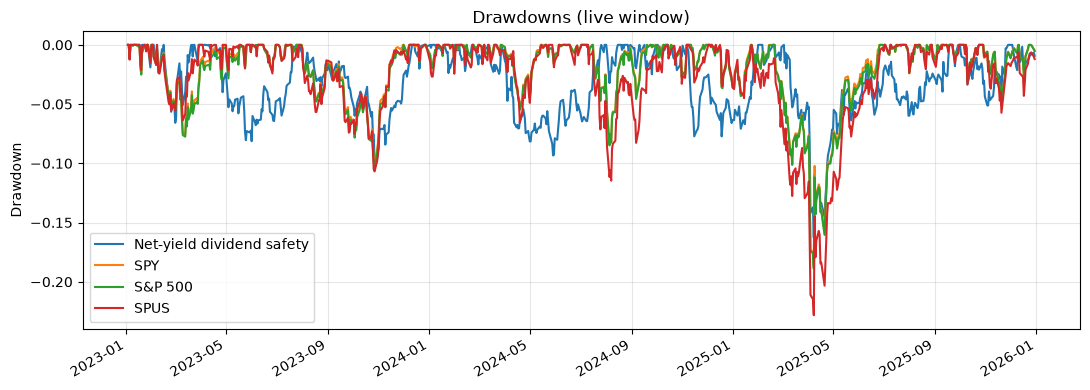

,Net-yield dividend safety,SPY,S&P 500,SPUS
Year,,,,
2023,33.43%,26.18%,24.23%,34.20%
2024,8.93%,24.89%,23.31%,26.50%
2025,20.56%,18.60%,17.25%,20.69%


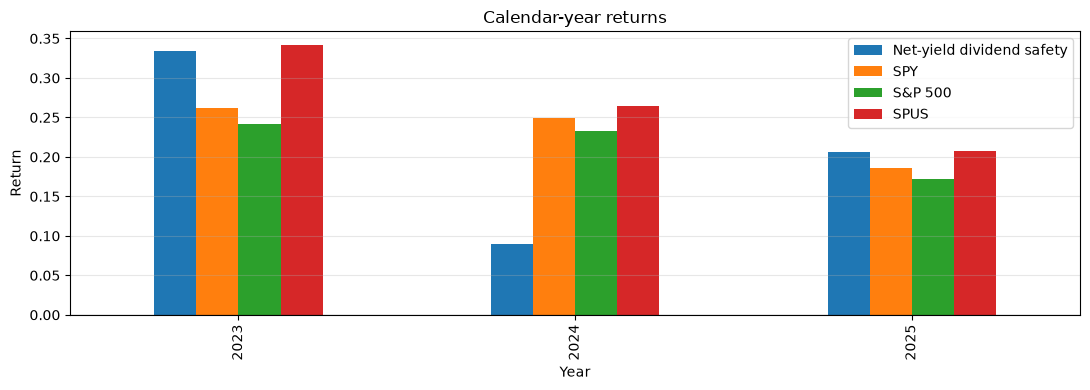

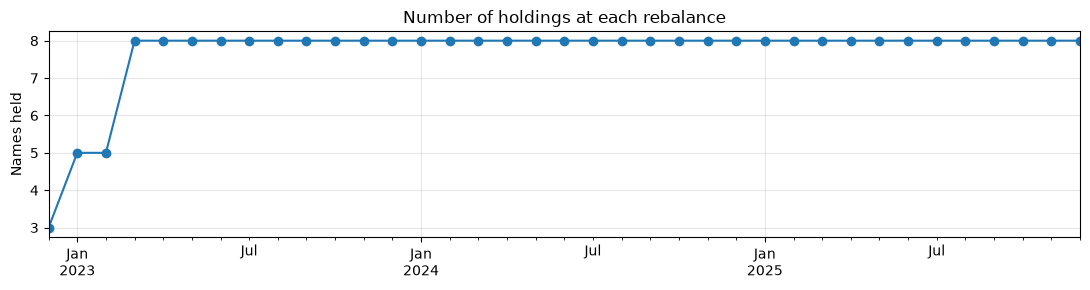

Holdings: min=3  median=8  max=8


,n,avg_gross,avg_net,avg_impure,med_coverage
as_of,,,,,
2025-01-31 00:00:00,8,2.32%,2.29%,0.95%,2.13x
2025-02-28 00:00:00,8,2.23%,2.20%,1.15%,2.13x
2025-03-31 00:00:00,8,2.21%,2.18%,1.14%,1.61x
2025-04-30 00:00:00,8,1.82%,1.80%,1.01%,1.97x
2025-05-31 00:00:00,8,1.77%,1.75%,1.01%,1.97x
2025-06-30 00:00:00,8,1.76%,1.74%,1.01%,1.96x
2025-07-31 00:00:00,8,1.80%,1.78%,1.01%,1.93x
2025-08-31 00:00:00,8,1.74%,1.72%,1.04%,1.93x
2025-09-30 00:00:00,8,1.69%,1.67%,1.04%,1.98x


Sample averages — gross yield 2.28%  ·  net yield 2.27%  ·  impure 0.71%  ·  median coverage 2.13x


In [ ]:
# Drawdowns from running peaks (live window)
equity_live = (1 + main_panel).cumprod()
drawdowns = equity_live / equity_live.cummax() - 1
drawdowns.plot(figsize=(11, 4), title="Drawdowns (live window)")
plt.ylabel("Drawdown")
plt.xlabel("")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(fig_dir / "drawdowns.png", dpi=140)
plt.show()

# Calendar-year returns
yearly = (1 + main_panel).resample("YE").prod() - 1
yearly.index = yearly.index.year
yearly.index.name = "Year"
display(yearly.style.format("{:.2%}").set_caption("Calendar-year returns (live window)"))

yearly.plot(kind="bar", figsize=(11, 4), title="Calendar-year returns")
plt.ylabel("Return")
plt.axhline(0, color="black", linewidth=0.8)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(fig_dir / "calendar-year-returns.png", dpi=140)
plt.show()

# How many names were held each month
if selections.empty:
    print("No holdings log — skip concentration chart.")
else:
    holdings_count = selections.groupby("as_of")["symbol"].nunique().sort_index()
    holdings_count.index = pd.to_datetime(holdings_count.index)
    holdings_count.plot(
        figsize=(11, 3),
        marker="o",
        title="Number of holdings at each rebalance",
    )
    plt.ylabel("Names held")
    plt.xlabel("")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(fig_dir / "holdings-count.png", dpi=140)
    plt.show()
    print(
        f"Holdings: min={int(holdings_count.min())}  "
        f"median={holdings_count.median():.0f}  "
        f"max={int(holdings_count.max())}"
    )

    # Income / safety diagnostics on the live book
    income_diag = (
        selections.groupby("as_of")
        .agg(
            n=("symbol", "nunique"),
            avg_gross=("gross_yield", "mean"),
            avg_net=("net_yield", "mean"),
            avg_impure=("impure_ratio", "mean"),
            med_coverage=("coverage", "median"),
        )
        .sort_index()
    )
    income_diag.index = pd.to_datetime(income_diag.index)
    display(
        income_diag.tail(12).style.format({
            "avg_gross": "{:.2%}",
            "avg_net": "{:.2%}",
            "avg_impure": "{:.2%}",
            "med_coverage": "{:.2f}x",
        }).set_caption("Live-book yield & coverage (last 12 rebalances)")
    )
    print(
        f"Sample averages — gross yield {income_diag['avg_gross'].mean():.2%}  ·  "
        f"net yield {income_diag['avg_net'].mean():.2%}  ·  "
        f"impure {income_diag['avg_impure'].mean():.2%}  ·  "
        f"median coverage {income_diag['med_coverage'].median():.2f}x"
    )


## Step 9 — Does higher net yield actually earn more?

Split every Halal name that clears the coverage and impure screens into five buckets by **net post-purification yield**. Each bucket is cap-weighted.

- **Q1** = highest net yield (what the live rule leans toward)
- **Q5** = lowest net yield

If the purification-adjusted yield signal is real, Q1 should beat Q5 on total return *and* show less realized purification drag in Step 11.


,CAGR,Volatility,Sharpe,Sortino,Max Drawdown,Calmar
Strategy,,,,,,
Q1,22.69%,22.34%,0.94,1.14,-19.86%,1.14
Q2,8.97%,17.97%,0.46,0.65,-14.34%,0.63
Q3,5.68%,19.12%,0.28,0.41,-20.53%,0.28
Q4,15.39%,28.02%,0.58,0.81,-36.81%,0.42
Q5,35.05%,28.87%,1.12,1.50,-34.23%,1.02


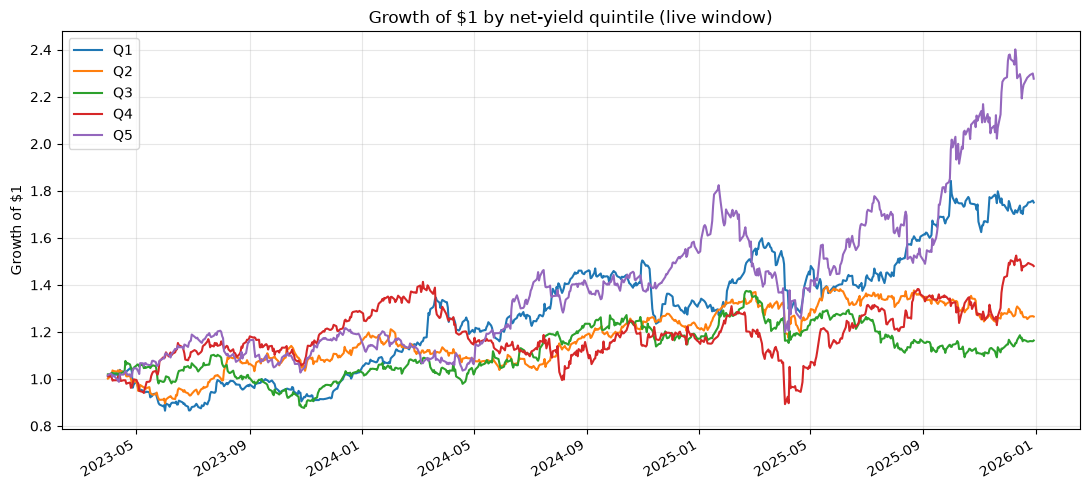

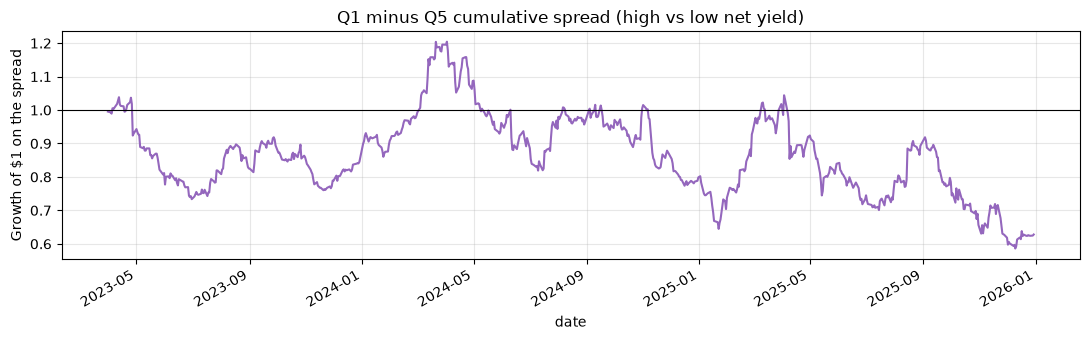

Q1−Q5 annualized spread: -11.25%  ·  hit rate (Q1 beats Q5 that day): 48.1%


In [ ]:
def cap_weighted_returns(
    weights_by_date: dict[date, pd.Series],
    daily_returns: pd.DataFrame,
) -> pd.Series:
    """Daily returns from a {rebalance_date: symbol-weight Series} map."""
    rebal = sorted(weights_by_date)
    active_w = pd.Series(dtype=float)
    last: date | None = None
    live = False
    rows: list[float] = []

    for dt in daily_returns.index:
        if dt.date() < pd.Timestamp(START).date():
            rows.append(np.nan)
            continue
        prior = [d for d in rebal if pd.Timestamp(d) <= dt]
        if prior and prior[-1] != last:
            active_w = weights_by_date.get(prior[-1], pd.Series(dtype=float))
            last = prior[-1]
            if not active_w.empty:
                live = True
        if not live:
            rows.append(np.nan)
            continue
        held = [s for s in active_w.index if s in daily_returns.columns]
        w = active_w.reindex(held).astype(float)
        w = w[w > 0]
        if w.empty:
            rows.append(0.0)
            continue
        w = w / w.sum()
        day_ret = (daily_returns.loc[dt, w.index] * w).sum(skipna=True)
        rows.append(0.0 if pd.isna(day_ret) else float(day_ret))

    return pd.Series(rows, index=pd.to_datetime(daily_returns.index), name="return")


N_Q = 5
scored_panel = attach_latest_fcf(metrics, fcf_history)
screener = AAOIFIScreener(debt_threshold=DEBT_THRESHOLD)
price_panel = (
    prices[prices["symbol"].isin(eligible_universe)]
    .pivot(index="date", columns="symbol", values="adj_close")
    .sort_index()
    .ffill()
)
stock_returns = price_panel.pct_change(fill_method=None)

quantile_w: dict[int, dict[date, pd.Series]] = {q: {} for q in range(1, N_Q + 1)}
for as_of in rebalance_dates:
    # keep_quantile=1.0 returns the full coverage-safe Halal pool, ranked by net yield
    ranked = select_dividend_safety(
        scored_panel,
        price_panel,
        dividend_history,
        as_of=as_of,
        rank_col="net_yield",
        keep_quantile=1.0,
        min_holdings=1,
        screener=screener,
    )
    if ranked.empty:
        continue
    ranked = ranked.sort_values("net_yield", ascending=False)
    n = len(ranked)
    if n < N_Q * 2:
        continue
    edges = np.linspace(0, n, N_Q + 1).astype(int)
    for q in range(N_Q):
        chunk = assign_cap_weights(ranked.iloc[edges[q] : edges[q + 1]].copy())
        quantile_w[q + 1][as_of] = chunk.set_index("symbol")["weight"].astype(float)

quantile_returns = pd.DataFrame(
    {
        f"Q{q}": cap_weighted_returns(quantile_w[q], stock_returns)
        for q in range(1, N_Q + 1)
    }
)
quantile_live = quantile_returns.reindex(main_panel.index).dropna(how="any")

if quantile_live.empty:
    print("Not enough names for a clean quintile sort in this window — skip.")
else:
    q_rows = [calc_performance_stats(quantile_live[col], col) for col in quantile_live.columns]
    q_stats = pd.DataFrame(q_rows).set_index("Strategy")
    display(q_stats.style.format(formatters).set_caption(
        "Net-yield quintiles inside the coverage-safe Halal pool  ·  Q1 = highest net yield, cap-weighted"
    ))

    q_equity = (1 + quantile_live).cumprod()
    q_equity.plot(figsize=(11, 5), title="Growth of $1 by net-yield quintile (live window)")
    plt.ylabel("Growth of $1")
    plt.xlabel("")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(fig_dir / "quintile-growth.png", dpi=140)
    plt.show()

    if {"Q1", "Q5"}.issubset(quantile_live.columns):
        spread = quantile_live["Q1"] - quantile_live["Q5"]
        spread_equity = (1 + spread).cumprod()
        spread_equity.plot(
            figsize=(11, 3.5),
            color="tab:purple",
            title="Q1 minus Q5 cumulative spread (high vs low net yield)",
        )
        plt.axhline(1.0, color="black", linewidth=0.8)
        plt.ylabel("Growth of $1 on the spread")
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig(fig_dir / "quintile-spread.png", dpi=140)
        plt.show()
        print(
            f"Q1−Q5 annualized spread: {spread.mean() * 252:.2%}  ·  "
            f"hit rate (Q1 beats Q5 that day): {(quantile_live['Q1'] > quantile_live['Q5']).mean():.1%}"
        )


## Step 10 — Attribution: stock picking or a hidden sector bet?

White-paper section 4 asks whether the result is really post-purification yield safety, or just “we accidentally owned more staples / utilities.”

- **Beta / alpha / tracking error** vs SPY and SPUS
- **Sector mix** — average industry weights of holdings versus an equal-weight Halal S&P basket


,Alpha (ann.),Beta,R²,Tracking error,Information ratio
Benchmark,,,,,
SPY,4.68%,0.66,0.41,13.20%,-0.16
S&P 500,5.40%,0.68,0.41,13.13%,-0.05
SPUS,6.07%,0.51,0.32,15.70%,-0.35


,Net-yield book (avg. month),Halal universe (equal weight),Delta
healthcare,52.3%,14.3%,38.0%
technology,42.1%,22.4%,19.7%
consumer defensive,3.6%,2.0%,1.5%
industrials,3.4%,8.2%,-4.8%
consumer cyclical,0.0%,14.3%,-14.3%
utilities,0.0%,12.2%,-12.2%
communication services,0.0%,8.2%,-8.2%
financial services,0.0%,6.1%,-6.1%
basic materials,0.0%,4.1%,-4.1%
real estate,0.0%,4.1%,-4.1%


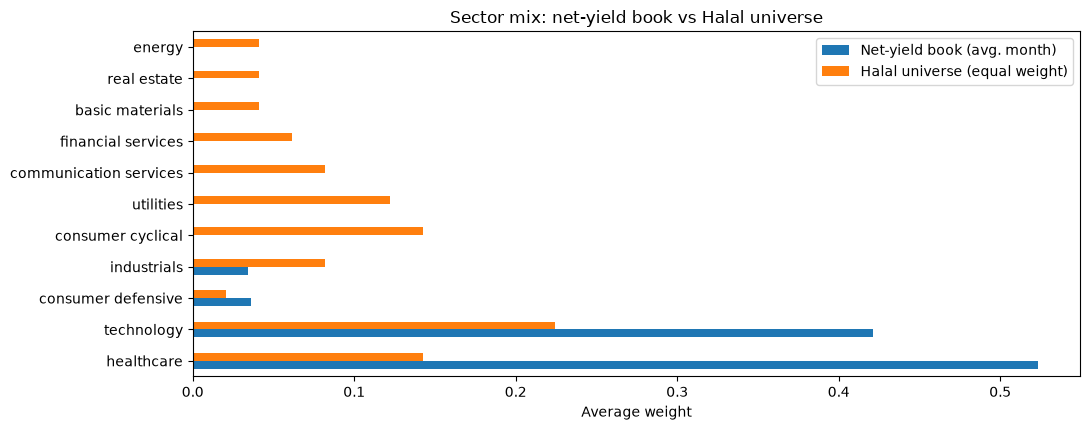

In [ ]:
def capm_attribution(strategy: pd.Series, benchmark: pd.Series, rf: float = RISK_FREE_RATE) -> dict:
    """Alpha, beta, R², tracking error vs one benchmark (daily, then annualized)."""
    aligned = pd.concat([strategy, benchmark], axis=1, keys=["y", "x"]).dropna()
    rf_d = rf / 252
    ye = aligned["y"] - rf_d
    xe = aligned["x"] - rf_d
    var_x = xe.var()
    beta = float(ye.cov(xe) / var_x) if var_x > 0 else np.nan
    alpha_d = float(ye.mean() - beta * xe.mean()) if pd.notna(beta) else np.nan
    resid = ye - alpha_d - beta * xe
    r2 = 1 - resid.var() / ye.var() if ye.var() > 0 else np.nan
    excess = aligned["y"] - aligned["x"]
    te = float(excess.std() * np.sqrt(252))
    ir = float(excess.mean() * 252 / te) if te > 0 else np.nan
    return {
        "Alpha (ann.)": alpha_d * 252,
        "Beta": beta,
        "R²": r2,
        "Tracking error": te,
        "Information ratio": ir,
    }


attr_rows = []
for bench_name in BENCHMARKS:
    row = capm_attribution(main_panel[STRATEGY_LABEL], main_panel[bench_name])
    row["Benchmark"] = bench_name
    attr_rows.append(row)
attr = pd.DataFrame(attr_rows).set_index("Benchmark")
display(
    attr.style.format({
        "Alpha (ann.)": "{:.2%}",
        "Beta": "{:.2f}",
        "R²": "{:.2f}",
        "Tracking error": "{:.2%}",
        "Information ratio": "{:.2f}",
    }).set_caption("Net-yield dividend safety vs each benchmark (live window)")
)

if "activity_labels" not in globals():
    _, _, activity_labels = apply_sector_screen(list(eligible_universe))

universe_w = (
    pd.Series({s: activity_labels.get(s, "Unclassified") for s in eligible_universe})
    .value_counts(normalize=True)
    .rename("Halal universe (equal weight)")
)

if selections.empty:
    print("No holdings log — skip sector mix.")
else:
    month_weights = []
    for as_of, snap in selections.groupby("as_of"):
        w = snap["weight"] if "weight" in snap.columns else 1 / len(snap)
        month_weights.append(
            snap.assign(weight=w)
            .assign(sector=lambda d: d["symbol"].map(activity_labels).fillna("Unclassified"))
            .groupby("sector")["weight"]
            .sum()
        )
    strat_w = pd.concat(month_weights, axis=1).mean(axis=1).rename("Net-yield book (avg. month)")
    sector_mix = pd.concat([strat_w, universe_w], axis=1).fillna(0.0)
    sector_mix["Delta"] = sector_mix["Net-yield book (avg. month)"] - sector_mix["Halal universe (equal weight)"]
    sector_mix = sector_mix.sort_values("Net-yield book (avg. month)", ascending=False)
    display(sector_mix.style.format("{:.1%}").set_caption(
        "Average sector weights  ·  delta = strategy minus Halal universe"
    ))
    sector_mix.drop(columns="Delta").plot(
        kind="barh",
        figsize=(11, max(4, 0.4 * len(sector_mix))),
        title="Sector mix: net-yield book vs Halal universe",
    )
    plt.xlabel("Average weight")
    plt.tight_layout()
    plt.savefig(fig_dir / "sector-mix.png", dpi=140)
    plt.show()


## Step 11 — Friction: turnover, trading costs, purification

A paper result that ignores costs is an upper bound. This section asks what is left after three real-world leaks:

1. **Turnover** — each month we sell some names and buy others
2. **Trading cost** — subtract `COST_BPS` (default 10 bps) on each one-way trade
3. **Purification** — a slice of dividend income tied to impure revenue is given away; here it is both a **selection input** and a **realized drag**

Compare purification drag on the **net-yield book** vs the **gross-yield twin**. The white-paper claim is that ranking by net yield should reduce that drag.


Fetching dividend purification for net-yield book …
Fetching dividend purification for gross-yield twin …


Item,Value
Rebalances with holdings,37
Average names held,7.7
Annualized one-way turnover,89.3%
Assumed cost per one-way trade,10 bps
Estimated annual trading-cost drag,0.09%
CAGR gross of trading costs,20.71%
CAGR net of trading costs,20.56%
Purification drag (net-yield book),0.02%
Purification drag (gross twin),0.02%
Dividend events while held (net book),88


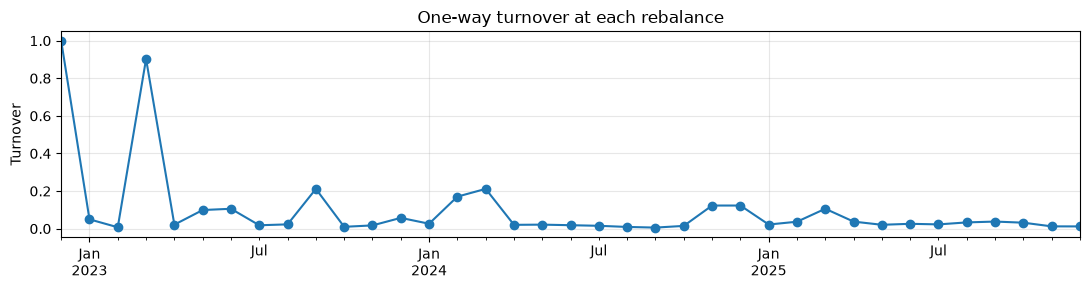

,symbol,ex_date,dividend,impure_ratio,purification_amount
0,A,2023-04-03 00:00:00,0.225,0.13%,0.0003
1,A,2023-06-30 00:00:00,0.225,0.13%,0.0003
2,A,2023-10-02 00:00:00,0.225,0.13%,0.0003
3,A,2023-12-29 00:00:00,0.236,0.75%,0.0018
4,A,2024-04-01 00:00:00,0.236,0.75%,0.0018
5,A,2024-07-02 00:00:00,0.236,0.75%,0.0018
6,A,2024-10-01 00:00:00,0.236,0.75%,0.0018
7,A,2024-12-31 00:00:00,0.248,1.23%,0.0030
8,A,2025-04-01 00:00:00,0.248,1.23%,0.0030
9,A,2025-07-01 00:00:00,0.248,1.23%,0.0030


In [ ]:
def one_way_turnover(old: dict[str, float], new: dict[str, float]) -> float:
    """Half L1 distance between two weight books (0 = no trades, 1 = full replace)."""
    if not new:
        return 0.0
    if not old:
        return 1.0
    names = set(old) | set(new)
    return 0.5 * sum(abs(new.get(s, 0.0) - old.get(s, 0.0)) for s in names)


def estimate_purification_drag(
    selection_log: pd.DataFrame,
    price_panel: pd.DataFrame,
    live_index: pd.DatetimeIndex,
    label: str,
) -> tuple[float, pd.DataFrame, int]:
    """Annualized purification drag on dividends received while names were held."""
    if selection_log.empty:
        return np.nan, pd.DataFrame(), 0

    held_symbols = sorted(selection_log["symbol"].unique())
    try:
        purified = hq.purify_dividends(
            held_symbols,
            start=str(live_index.min().date()),
            end=END,
        )
    except Exception as exc:
        print(f"[{label}] Purification lookup failed ({exc}).")
        return np.nan, pd.DataFrame(), 0

    if purified is None or purified.empty:
        print(f"[{label}] No purification rows — report as a data gap, not 0% drag.")
        return np.nan, pd.DataFrame(), 0

    held_flags = []
    for as_of, snap in selection_log.groupby("as_of"):
        held_flags.append(pd.DataFrame({"as_of": pd.Timestamp(as_of), "symbol": snap["symbol"].tolist()}))
    held_log = pd.concat(held_flags, ignore_index=True)

    purified = purified.copy()
    purified["ex_date"] = pd.to_datetime(purified["ex_date"])
    px = price_panel.copy()
    px.index = pd.to_datetime(px.index)

    # Cap-weight when available
    weight_lookup = {}
    for as_of, snap in selection_log.groupby("as_of"):
        if "weight" in snap.columns:
            weight_lookup[pd.Timestamp(as_of)] = snap.set_index("symbol")["weight"].astype(float).to_dict()
        else:
            weight_lookup[pd.Timestamp(as_of)] = {s: 1.0 / len(snap) for s in snap["symbol"]}

    drag_rows = []
    for _, div in purified.iterrows():
        symbol = div["symbol"]
        ex = div["ex_date"]
        prior_rebal = held_log.loc[held_log["as_of"] <= ex]
        if prior_rebal.empty:
            continue
        last_asof = prior_rebal["as_of"].max()
        book_w = weight_lookup.get(last_asof, {})
        if symbol not in book_w:
            continue
        if symbol not in px.columns:
            continue
        hist = px.loc[:ex, symbol].dropna()
        if hist.empty or hist.iloc[-1] <= 0:
            continue
        amount = div.get("purification_amount")
        if pd.isna(amount):
            continue
        drag_rows.append(float(amount) / float(hist.iloc[-1]) * float(book_w[symbol]))

    years = len(live_index) / 252
    purify_drag = (sum(drag_rows) / years) if years > 0 else np.nan
    return purify_drag, purified, len(drag_rows)


if selections.empty:
    raise RuntimeError("No holdings log — re-run the backtest cell first.")

if "price_panel" not in globals():
    price_panel = (
        prices[prices["symbol"].isin(eligible_universe)]
        .pivot(index="date", columns="symbol", values="adj_close")
        .sort_index()
        .ffill()
    )

rebal_order = sorted(selections["as_of"].unique())
turnover_rows = []
prev: dict[str, float] = {}
for as_of in rebal_order:
    snap = selections.loc[selections["as_of"] == as_of]
    if "weight" in snap.columns:
        curr = snap.set_index("symbol")["weight"].astype(float).to_dict()
    else:
        curr = {s: 1.0 / len(snap) for s in snap["symbol"]}
    turnover_rows.append({"as_of": pd.Timestamp(as_of), "one_way": one_way_turnover(prev, curr), "n": len(curr)})
    prev = curr

turnover = pd.DataFrame(turnover_rows).set_index("as_of")
months = max(len(turnover) - 1, 1)
annual_turnover = turnover["one_way"].iloc[1:].sum() * (12 / months) if len(turnover) > 1 else np.nan
cost_drag_ann = annual_turnover * COST_BPS / 10_000

cost_on_day = pd.Series(0.0, index=main_panel.index)
for as_of, row in turnover.iterrows():
    hit = main_panel.index[main_panel.index >= as_of]
    if len(hit):
        cost_on_day.loc[hit[0]] += float(row["one_way"]) * COST_BPS / 10_000

net_returns = main_panel[STRATEGY_LABEL] - cost_on_day
net_stats = calc_performance_stats(net_returns, f"{STRATEGY_LABEL} net of {COST_BPS} bps")
gross_cagr = calc_performance_stats(main_panel[STRATEGY_LABEL], STRATEGY_LABEL)["CAGR"]

print("Fetching dividend purification for net-yield book …")
net_drag, purified_net, n_net_events = estimate_purification_drag(
    selections, price_panel, main_panel.index, STRATEGY_LABEL
)
print("Fetching dividend purification for gross-yield twin …")
gross_drag, purified_gross, n_gross_events = estimate_purification_drag(
    gross_selections, price_panel, gross_panel.index if not gross_panel.empty else main_panel.index, GROSS_LABEL
)

friction = pd.DataFrame(
    {
        "Item": [
            "Rebalances with holdings",
            "Average names held",
            "Annualized one-way turnover",
            "Assumed cost per one-way trade",
            "Estimated annual trading-cost drag",
            "CAGR gross of trading costs",
            "CAGR net of trading costs",
            "Purification drag (net-yield book)",
            "Purification drag (gross twin)",
            "Dividend events while held (net book)",
        ],
        "Value": [
            f"{len(turnover)}",
            f"{turnover['n'].mean():.1f}",
            f"{annual_turnover:.1%}",
            f"{COST_BPS} bps",
            f"{cost_drag_ann:.2%}",
            f"{gross_cagr:.2%}",
            f"{net_stats['CAGR']:.2%}",
            f"{net_drag:.2%}" if pd.notna(net_drag) else "data gap",
            f"{gross_drag:.2%}" if pd.notna(gross_drag) else "data gap",
            f"{n_net_events}",
        ],
    }
)
display(friction.style.hide(axis="index"))

turnover["one_way"].plot(figsize=(11, 3), marker="o", title="One-way turnover at each rebalance")
plt.ylabel("Turnover")
plt.xlabel("")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(fig_dir / "turnover.png", dpi=140)
plt.show()

if not purified_net.empty:
    display(
        purified_net[["symbol", "ex_date", "dividend", "impure_ratio", "purification_amount"]]
        .head(12)
        .style.format({"dividend": "{:.3f}", "impure_ratio": "{:.2%}", "purification_amount": "{:.4f}"}, na_rep="—")
        .set_caption("Sample purified dividends (net-yield book holdings)")
    )


### Notes on methodology

- **Point-in-time:** `halalquant.get_financial_metrics(..., freq="ME")` uses SEC `filed_date` (or report date + 90 days for non-US filers) so rebalance decisions never use future filings.
- **FCF source:** Free cash flow comes from yfinance annual cash-flow statements with the same 90-day publication lag. Yahoo typically only stores a few annual periods, so the book may go live later than `START`.
- **Dividends:** TTM dividends are the sum of cash dividends with ex-dates in the trailing 365 days. Gross yield = TTM DPS / price. Coverage uses TTM dividends × shares proxy (`market_cap / price`).
- **Impure ratio / net yield:** `impure_ratio` from the metrics panel (and `purify_dividends` for realized drag). Names with missing impure ratios are **excluded** from selection — missing is a gap, not a free pass to 0% haircut. Live rule: `impure_ratio < 5%`, then \(Y^{net} = Y^{gross}\times(1-\rho)\).
- **Selection:** Halal AAOIFI filter → impure `< 5%` → FCF coverage `≥ 1` → top `KEEP_QUANTILE` by **net yield**, cap-weighted. The gross twin only changes the ranking column.
- **Live-window stats:** Days before the first real holdings are missing, not 0%. Benchmarks are sliced to that same window.
- **Quintiles:** Q1–Q5 split the coverage-safe Halal pool by net yield. Q1 is highest net yield (near the live book).
- **Friction:** Turnover is half the L1 weight change between monthly books. Trading-cost drag applies `COST_BPS` on each one-way turn. Purification drag is estimated for both books so the paper can test whether net-yield ranking reduces dividend drag.
- **Benchmarks:** SPY (tradable S&P 500 ETF), `^GSPC` (S&P 500 index), SPUS (Halal large-cap ETF).
- **Runtime:** `FAST_MODE = False` runs the full S&P 500 (~15–45 min depending on network). Figures save to `Research/papers/07-net-div-safety/figures/`.
- **White-paper map:** Step 7 → section 3; Steps 8–9 → section 3 extras; Step 10 → section 4; Step 11 → section 5. Hypothesis and strategy rules (sections 1–2) are written in the paper, not computed here.
- **Survivorship:** the S&P 500 list is current; historical membership is not reconstructed. Treat results as exploratory research, not a live mandate.


## Summary

| Component | Rule |
| --- | --- |
| Universe | S&P 500 → Halal sector screen → AAOIFI financial ratios |
| Impure screen | `impure_ratio < 5%` (required non-null) |
| Safety screen | TTM FCF / TTM dividends `≥ 1` |
| Signal | Net post-purification yield \(Y^{net} = Y^{gross} \times (1 - \rho)\) |
| Portfolio | Top quintile by net yield, cap-weighted, monthly rebalance |
| Control twin | Same screens, ranked by **gross** yield |
| Window | 2020-01-01 → 2025-12-31 |
| Benchmarks | SPY, S&P 500 (`^GSPC`), SPUS |
| Focus metric | Purification drag vs gross twin; net income after costs |

Re-run with `FAST_MODE = False` for the paper figures. Kill or revise the idea if the net-yield book does not reduce purification drag (or net income after costs) relative to the gross twin once sector tilt is accounted for.
